## Data preparation
### it builds and saves necessary kinematic variables to be used at training

In [1]:
############
import sys, os
import numpy as np
import pandas as pd
sys.path.insert(0, '/eos/lhcb/user/h/havva/q2Measurement-BtoDstMuNu/GaussianProcessRegression/Packages/AmpliTF/')
import amplitf.interface as atfi
import amplitf.kinematics as atfk
import uproot
from util_resolution import return_phasespace, get4mom, return_quadsolution, return_boostapprox
############

year = 2016#2016#2017,2018
magnets = ['up','down']
base_mc_path = f"/eos/lhcb/user/h/havva/q2Measurement-BtoDstMuNu/MCsamples/TrackerOnlyNTuples_Maryland/Angular_RDst_muonic_Run2/ReProcess_tuples/{year}"
# Components and file mapping
'''components = [
    "b0_dstmu"#, 
]'''
'''file_map = {
    "signal": "b0_dstmu/b0_dstmunu",
    "b0_dsttau": "b0_dsttau/b0_dsttaunu",
    "b0_dststtau": "b_dststtau/b0_dststtau",
    "b+_dststtau": "b_dststtau/b+_dststtau",
    "b+_dstdx": "DDX/b+_dstdx",
    "b0_dstdx": "DDX/b0_dstdx",
    "b0_dststmu": "b_dststmu/b0_dststmu",
    "b+_dststmu": "b_dststmu/b+_dststmu",
    "bs_dststmu": "bs_dststmu/bs_dststmu",
    "b0_dststmu_415": "b_dststmu/b0_dststmu",
    "b0_dststmu_10413": "b_dststmu/b0_dststmu",
    "b0_dststmu_20413": "b_dststmu/b0_dststmu",
    "b+_dststmu_425": "b_dststmu/b+_dststmu",
    "b+_dststmu_10423": "b_dststmu/b+_dststmu",
    "b+_dststmu_20423": "b_dststmu/b+_dststmu",
    "bs_dststmu_10433": "bs_dststmu/bs_dststmu",
    "bs_dststmu_435": "bs_dststmu/bs_dststmu",
    "b+_dststmu_heavy": "b_dststmu_heavy/b+_dststmu_heavy",
    "b0_dststmu_heavy": "b_dststmu_heavy/b0_dststmu_heavy"
}
'''
selected_branches = [
    "b0_PX", "b0_PY", "b0_PZ", "b0_PE","b0_P","b0_PT",
    "mu_PX", "mu_PY", "mu_PZ", "mu_PE", "mu_P","mu_PT",
    "dst_PX", "dst_PY", "dst_PZ", "dst_PE", "dst_P","dst_PT",
    "d0_PX", "d0_PY", "d0_PZ", "d0_PE", "d0_PT", "d0_P",
    "spi_PX", "spi_PY", "spi_PZ", "spi_PE", "spi_P","spi_PT",
    "k_PX", "k_PY","k_PZ", "k_PE","k_P","k_PT", 
    "pi_PX", "pi_PY", "pi_PZ", "pi_PE", "pi_P","pi_PT",
    "b0_TRUEP_X", "b0_TRUEP_Y", "b0_TRUEP_Z", "b0_TRUEP_E","b0_TRUEPT",
    "pi_ETA", "k_ETA", "mu_ETA",
    #"b0_TRUEENDVERTEX_X", "b0_TRUEENDVERTEX_Y", "b0_TRUEENDVERTEX_Z",
    #"b0_TRUEORIGINVERTEX_X", "b0_TRUEORIGINVERTEX_Y", "b0_TRUEORIGINVERTEX_Z",
    "mu_TRUEP_X", "mu_TRUEP_Y", "mu_TRUEP_Z", "mu_TRUEP_E","mu_TRUEPT",
    "dst_TRUEP_X", "dst_TRUEP_Y", "dst_TRUEP_Z", "dst_TRUEP_E","dst_TRUEPT",
    "d0_TRUEP_X", "d0_TRUEP_Y", "d0_TRUEP_Z", "d0_TRUEP_E","d0_TRUEPT",
    "spi_TRUEP_X", "spi_TRUEP_Y", "spi_TRUEP_Z", "spi_TRUEP_E","spi_TRUEPT",
    "k_TRUEP_X", "k_TRUEP_Y", "k_TRUEP_Z", "k_TRUEP_E","k_TRUEPT",
    "pi_TRUEP_X", "pi_TRUEP_Y", "pi_TRUEP_Z","pi_TRUEPT",
    "b0_ENDVERTEX_X", "b0_ENDVERTEX_Y", "b0_ENDVERTEX_Z","b0_DIRA_OWNPV",
    "b0_OWNPV_X", "b0_OWNPV_Y", "b0_OWNPV_Z","b0_IP_OWNPV","b0_IPCHI2_OWNPV", 
    "b0_FDCHI2_OWNPV", "b0_FD_OWNPV", "b0_OWNPV_CHI2", "b0_OWNPV_NDOF",
    "k_IP_OWNPV","k_IPCHI2_OWNPV",
    "pi_IP_OWNPV", "pi_IPCHI2_OWNPV",
    "d0_IP_OWNPV", "d0_IPCHI2_OWNPV", "d0_FDCHI2_OWNPV","d0_FD_OWNPV", 
    "d0_DIRA_ORIVX","d0_DIRA_OWNPV","d0_ORIVX_CHI2", "d0_ORIVX_NDOF",
    "d0_OWNPV_CHI2","d0_OWNPV_NDOF",
    "dst_FDCHI2_OWNPV", "dst_IPCHI2_OWNPV", "dst_IP_OWNPV",
    "mu_IP_OWNPV","mu_IPCHI2_OWNPV",
    "dst_M", "b0_M", "d0_M",
    "b0_ISOLATION_BDT",
    "b0_TRUEID", "dst_TRUEID", "d0_TRUEID", "spi_TRUEID", "mu_TRUEID","mu_MC_MOTHER_ID",
    "b0_TrueHadron_D0_ID","b0_TrueHadron_D1_ID","b0_TrueHadron_D2_ID",
    "b0_TrueHadron_D0_PE","b0_TrueHadron_D0_PX","b0_TrueHadron_D0_PY","b0_TrueHadron_D0_PZ",
    "mu_MC_MOTHER_TRUEPE","mu_MC_MOTHER_TRUEPX","mu_MC_MOTHER_TRUEPY","mu_MC_MOTHER_TRUEPZ",
    "b0_TrueHadron_D1_PE","b0_TrueHadron_D1_PX","b0_TrueHadron_D1_PY","b0_TrueHadron_D1_PZ",
    "b0_TrueHadron_D2_PE","b0_TrueHadron_D2_PX","b0_TrueHadron_D2_PY","b0_TrueHadron_D2_PZ",
    "b0_TrueTauNuTau_PE","b0_TrueTauNuTau_PX","b0_TrueTauNuTau_PY","b0_TrueTauNuTau_PZ",
    "b0_TrueTauNuMu_PE","b0_TrueTauNuMu_PX","b0_TrueTauNuMu_PY","b0_TrueTauNuMu_PZ",
    "b0_TrueNeutrino_PE","b0_TrueNeutrino_PX","b0_TrueNeutrino_PY","b0_TrueNeutrino_PZ",# From this line on: those might not be necessary!
    "b0_TrueMu_PE","b0_TrueMu_PX","b0_TrueMu_PY","b0_TrueMu_PZ",
    "b0_TrueTau_PE","b0_TrueTau_PX","b0_TrueTau_PY","b0_TrueTau_PZ",
    "nTracks","runNumber","eventNumber"
]


selected_branches += ['nu_TRUEP_E','nu_TRUEP_X','nu_TRUEP_Y','nu_TRUEP_Z',
    # True fit vars
    'costhetal_TRUE','costhetad_TRUE','chi_TRUE','q2_TRUE','mmiss2_TRUE','w_TRUE',
    'nu_PE','nu_PX','nu_PY','nu_PZ',
    'b0_Flight_X','b0_Flight_Y','b0_Flight_Z',
    # Reco fit vars
    'q2rec_quad','costhetalrec_quad','costhetadrec_quad','chirec_quad',
    'mmiss2rec_brf','q2rec_plus','q2rec_minus','w_rec_quad',
    # Weight branches 
    'pid_eff'
]

# True masses
mB = 5279.61000000
mDst = 2010.27000000
ml  = 105.65837121

#define aliases
scale_theta = 0.32573304165853184
scale_phi   = 0.3769516994536387

aliases = {}
aliases['b0_Flight_R'] = '((b0_ENDVERTEX_X - b0_OWNPV_X)**2 + (b0_ENDVERTEX_Y - b0_OWNPV_Y)**2 + (b0_ENDVERTEX_Z - b0_OWNPV_Z)**2)**0.5'
aliases['b0_Flight_Theta'] = 'atan2(((b0_ENDVERTEX_X - b0_OWNPV_X)**2 + (b0_ENDVERTEX_Y - b0_OWNPV_Y)**2)**0.5, (b0_ENDVERTEX_Z - b0_OWNPV_Z))'
aliases['b0_Flight_Phi'] = 'atan2((b0_ENDVERTEX_Y - b0_OWNPV_Y), (b0_ENDVERTEX_X - b0_OWNPV_X))'
aliases['b0_Flight_X'] = 'b0_Flight_R * sin(b0_Flight_Theta) * cos(b0_Flight_Phi)'
aliases['b0_Flight_Y'] = 'b0_Flight_R * sin(b0_Flight_Theta) * sin(b0_Flight_Phi)'
aliases['b0_Flight_Z'] = 'b0_Flight_R * cos(b0_Flight_Theta)'


component = "b0_dstmunu"
#for component in components:
for mag in magnets:
#    files  = [{f'{base_mc_path}/{file_map[component]}_{mag}_allVariables.root': 'DecayTree'}] 
    files  = [{f'{base_mc_path}/{component}_{mag}_allVariables.root': 'DecayTree'}] 
    #files  += [{f'{base_mc_path}/{file_map[component]}_down_allVariables.root': 'DecayTree'}] 

    df_base = (uproot.open(files[0])).arrays(expressions=list(set(selected_branches)), aliases = aliases, library='pd')#entry_stop = 20000,
    #df2 = (uproot.open(files[1])).arrays(expressions=list(set(selected_branches)), aliases = aliases, library='pd')
    #df_base  = pd.concat([df1, df2])

    #############
    #True variables
    Pdst_lab    = atfk.lorentz_vector(atfk.vector(df_base['dst_TRUEP_X'], df_base['dst_TRUEP_Y'] , df_base['dst_TRUEP_Z']), df_base['dst_TRUEP_E']) 
    Pl_lab     = atfk.lorentz_vector(atfk.vector(df_base['mu_TRUEP_X'], df_base['mu_TRUEP_Y'], df_base['mu_TRUEP_Z']), df_base['mu_TRUEP_E'])
    Pnu_lab    = atfk.lorentz_vector(atfk.vector(df_base['nu_TRUEP_X'], df_base['nu_TRUEP_Y'], df_base['nu_TRUEP_Z']), df_base['nu_TRUEP_E'])
    # D0 (or D+) from D*
    PD_lab = atfk.lorentz_vector(atfk.vector(df_base['d0_TRUEP_X'], df_base['d0_TRUEP_Y'], df_base['d0_TRUEP_Z']),df_base['d0_TRUEP_E'])
    # soft pion from D* → D π
    Ppi_lab = atfk.lorentz_vector(atfk.vector(df_base['spi_TRUEP_X'], df_base['spi_TRUEP_Y'], df_base['spi_TRUEP_Z']),df_base['spi_TRUEP_E'])
    Pb_lab    = Pdst_lab + Pl_lab + Pnu_lab

    #TRUE mom and fit vars
    df_base['b0_P_TRUE']       = atfk.p(atfk.spatial_components(Pb_lab)).numpy()
    '''df_base['Lepton_E_TRUE']   = atfk.time_component(Pl_lab).numpy()
    df_base['Lepton_P_TRUE']   = atfk.p(atfk.spatial_components(Pl_lab)).numpy()
    df_base['Lepton_PX_TRUE']  = atfk.spatial_components(Pl_lab)[:,0].numpy()
    df_base['Lepton_PY_TRUE']  = atfk.spatial_components(Pl_lab)[:,1].numpy()
    df_base['Lepton_PZ_TRUE']  = atfk.spatial_components(Pl_lab)[:,2].numpy()'''
    #q2, costhl, costhd, chi, El, MM2 since we are using mmiss2_brf for reco NO NEED FOR REGRESSION
    #def return_phasespace(Pb0_lab, Pdst_lab, PLepton_lab, PD_lab, Ppi_lab, Missmass2=True, convert_to_numpy=True):
    q2, costhl, costhd, chi,_ = return_phasespace(Pb_lab, Pdst_lab, Pl_lab, PD_lab,Ppi_lab,False, True)
    df_base['q2_TRUE'] = q2
    df_base['costhetal_TRUE']= costhl
    df_base['costhetad_TRUE']= costhd
    df_base['chi_TRUE'] = chi

    '''#1st mom and fit vars
    df_base['b0_P_TRUE_plus']=return_quadsolution(atfk.spatial_components(Pb_lab), mB**2, Pdst_lab, Pl_lab, solution = 'plus').numpy()
    Pb_lab_plus = get4mom(atfk.spatial_components(Pb_lab), df_base['b0_P_TRUE_plus'], mB)
    df_base['q2_TRUE_plus'], df_base['costhetal_TRUE_plus'], df_base['costhetad_TRUE_plus'], df_base['chi_TRUE_plus'] = return_phasespace(Pb_lab, Pdst_lab, Pl_lab, PD_lab,Ppi_lab,False, True)

    #2nd mom and fit vars
    df_base['b0_P_TRUE_minus']=return_quadsolution(atfk.spatial_components(Pb_lab), mB**2, Pdst_lab, Pl_lab, solution = 'minus').numpy()
    Pb_lab_minus = get4mom(atfk.spatial_components(Pb_lab), df_base['b0_P_TRUE_minus'], mB)
    df_base['q2_TRUE_minus'], df_base['costhetal_TRUE_minus'], df_base['costhetad_TRUE_minus'],df_base['chi_TRUE_minus'] = return_phasespace(Pb_lab, Pdst_lab, Pl_lab, PD_lab,Ppi_lab,False, True)

    '''
    ######################
    #Reco variables
    ## b0_P_ is spatial momentum
    p3_Bfd      = atfk.vector(df_base['b0_Flight_X'], df_base['b0_Flight_Y'], df_base['b0_Flight_Z'])
    Pdst_lab_r    = atfk.lorentz_vector(atfk.vector(df_base['dst_PX'], df_base['dst_PY'] , df_base['dst_PZ']), df_base['dst_PE']) 
    PLepton_lab_r= atfk.lorentz_vector(atfk.vector(df_base['mu_PX'], df_base['mu_PY'],  df_base['mu_PZ']), df_base['mu_PE'])
    # D0 (or D+) from D*
    PD_lab_r = atfk.lorentz_vector(atfk.vector(df_base['d0_PX'], df_base['d0_PY'], df_base['d0_PZ']),df_base['d0_PE'])
    # soft pion from D* → D π
    Ppi_lab_r = atfk.lorentz_vector(atfk.vector(df_base['spi_PX'], df_base['spi_PY'], df_base['spi_PZ']),df_base['spi_PE'])
    #Pb0_lab_r   = Pdst_lab_r + PLepton_lab
    '''df_base['Lepton_E_Reco']   = atfk.time_component(PLepton_lab_r).numpy()
    df_base['Lepton_P_Reco']   = atfk.p(atfk.spatial_components(PLepton_lab_r)).numpy()
    df_base['Lepton_PX_Reco']  = atfk.spatial_components(PLepton_lab_r)[:,0].numpy()
    df_base['Lepton_PY_Reco']  = atfk.spatial_components(PLepton_lab_r)[:,1].numpy()
    df_base['Lepton_PZ_Reco']  = atfk.spatial_components(PLepton_lab_r)[:,2].numpy()
    '''
    #1st mom and fit vars
    df_base['b0_P_plus']=return_quadsolution(p3_Bfd, mB**2, Pdst_lab_r, PLepton_lab_r, solution = 'plus').numpy()
    Pb_lab_plus_r = get4mom(p3_Bfd, df_base['b0_P_plus'], mB)
    q2_plus, costhetal_plus, costhetad_plus,chi_plus,_ = return_phasespace(Pb_lab_plus_r, Pdst_lab_r, PLepton_lab_r,PD_lab_r,Ppi_lab_r,False,True)
    
    df_base['q2_plus']= q2_plus
    df_base['costhetal_plus']= costhetal_plus 
    df_base['costhetad_plus']= costhetad_plus
    df_base['chi_plus'] = chi_plus

    #2nd mom and fit vars
    df_base['b0_P_minus']=return_quadsolution(p3_Bfd, mB**2, Pdst_lab_r, PLepton_lab_r, solution = 'minus').numpy()
    Pb_lab_minus_r = get4mom(p3_Bfd, df_base['b0_P_minus'], mB)
    q2_minus, costhetal_minus, costhetad_minus,chi_minus,_ = return_phasespace(Pb_lab_minus_r, Pdst_lab_r, PLepton_lab_r,PD_lab_r,Ppi_lab_r,False,True)
    
    df_base['q2_minus']= q2_minus
    df_base['costhetal_minus']= costhetal_minus
    df_base['costhetad_minus']= costhetad_minus
    df_base['chi_minus'] = chi_minus

    ## this is from return_quadsolution and if there is Nan solution in Bp that event gets deleted!!!
    #store reco vars 
    cond              = (df_base['q2rec_quad'].values == df_base['q2rec_plus'].values)
    df_base['b0_P_Reco']   = np.where(cond, df_base['b0_P_plus'].values,     df_base['b0_P_minus'].values)
    df_base['q2_Reco']     = np.where(cond, df_base['q2_plus'].values,       df_base['q2_minus'].values)
    df_base['w_Reco']     = (mB**2 + mDst**2 - df_base['q2_Reco']) / (2 * mB * mDst)
    df_base['costhetal_Reco'] = np.where(cond, df_base['costhetal_plus'].values, df_base['costhetal_minus'].values)
    df_base['costhetad_Reco'] = np.where(cond, df_base['costhetad_plus'].values, df_base['costhetad_minus'].values)
    df_base['chi_Reco']       = np.where(cond, df_base['chi_plus'].values,       df_base['chi_minus'].values)

    '''## This is REST FRAME APPROXIMATION which we only use for mmiss2 and WE DO NOT NEED NOW !!!!!
    p_b0_mu      = return_boostapprox(p3_Bfd, (Pdst_lab_r + PLepton_lab_r), mB)
    PBmu_lab_r  = get4mom(p3_Bfd, p_b0_mu, mB)
    df_base['b0Mu_P_Reco'] = atfk.p(atfk.spatial_components(PBmu_lab_r)).numpy()
    df_base['q2Mu_Reco'], df_base['costhetalrec_brf'], df_base['costhetadrec_brf'], df_base['mmiss2rec_brf'] = return_phasespace(PBmu_lab_r, Pdst_lab_r, PLepton_lab_r, True)
    '''
    df_base = df_base.dropna() #Nan and negative sqrt solutions from return_quadsolution
    print(df_base.shape)
    ######################
    indx = range(df_base.shape[0])
    df_base.index    = indx
    df_base['Index'] = indx
    print(df_base)
    os.makedirs(f'./{component}', exist_ok=True)
    print('Storing', f'./{component}/preppedData_{year}_{mag}.p')
    df_base.to_pickle(f'./{component}/preppedData_{year}_{mag}.p')


2026-02-04 05:55:54.401905: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 05:58:46.544204: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


I0000 00:00:1770181968.654744     333 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


(1518283, 206)
                d0_PY  b0_TrueHadron_D0_PE  d0_TRUEID         mu_PT  \
0         8265.798240         73710.507598       -421  14229.282829   
1        -1961.225939         54238.374950       -421   1628.509006   
2         4540.824072         65615.185285        421   1716.336362   
3         -141.713961        115021.734501       -421   1215.436296   
4         2377.697035         95330.164658        421   1647.877709   
...               ...                  ...        ...           ...   
1518278   -769.275772         61840.024047       -421   4330.010612   
1518279   5346.418097         69178.138508        421   1681.450891   
1518280  10341.676743         80461.829584        421   5233.023513   
1518281   4685.444868         89921.487164       -421   4502.416254   
1518282   6171.460081         92550.470289       -421   3440.536067   

               pi_PY  b0_TrueHadron_D1_PX         b0_PX  dst_IPCHI2_OWNPV  \
0        3948.158935                  0.0 -20924.855776

Storing ./b0_dstmunu/preppedData_2016_down.p


### Applying model prediction to whole dataset


=== Processing component: b0_dstmunu Mag up ===
Loaded dataset: (1518283, 207)


/cvmfs/sft-nightlies.cern.ch/lcg/views/dev3cuda/Tue/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


╒═════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════════════════════╕
│ name                                │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                                   │
╞═════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════════════════════╡
│ SGPR.mean_function.A                │ Parameter │ Identity         │         │ True        │ (9, 1)   │ float64 │ [[0.14744977...                         │
├─────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────────────────────┤
│ SGPR.mean_function.b                │ Parameter │ Identity         │         │ True        │ (1,)     │ float64 │ [0.]                                    │
├─────────────────────────────────────┼───────────┼─

I0000 00:00:1770183397.790483     333 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0xc7156ae0


Saved: b0_dstmunu/pickled_2016_up/regressed.p
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)


/eos/home-i02/h/havva/SWAN_projects/TensorFlow_Keras_MNIST/Ultimate_GPFlow/util_resolution.py:387: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Reco Rel after (1518283,)
Plots saved in b0_dstmunu/pickled_2016_up/plots

=== Processing component: b0_dstmunu Mag down ===
Loaded dataset: (1426191, 207)


/cvmfs/sft-nightlies.cern.ch/lcg/views/dev3cuda/Tue/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


╒═════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════════════════════╕
│ name                                │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                                   │
╞═════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════════════════════╡
│ SGPR.mean_function.A                │ Parameter │ Identity         │         │ True        │ (9, 1)   │ float64 │ [[0.14744977...                         │
├─────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────────────────────┤
│ SGPR.mean_function.b                │ Parameter │ Identity         │         │ True        │ (1,)     │ float64 │ [0.]                                    │
├─────────────────────────────────────┼───────────┼─

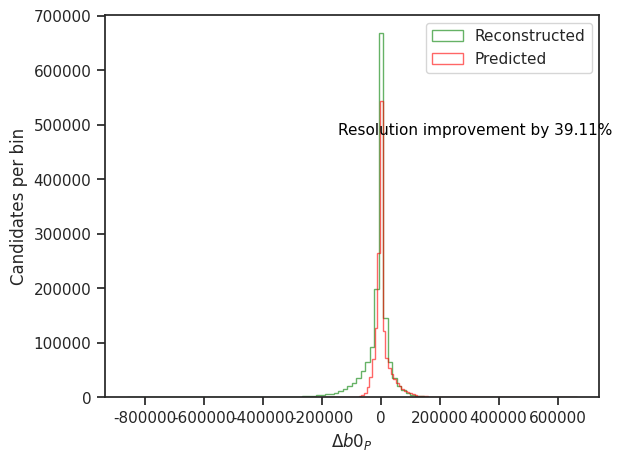

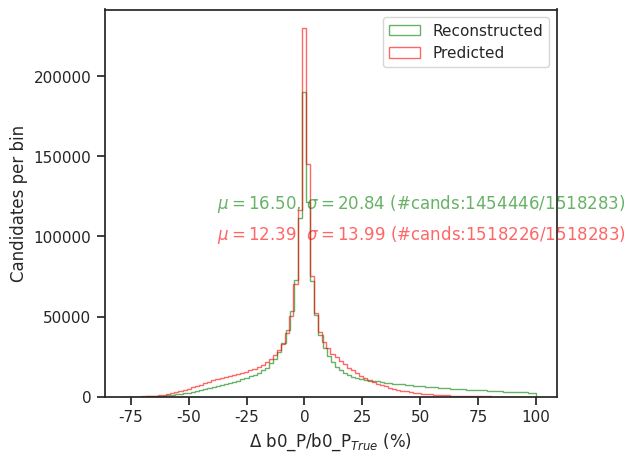

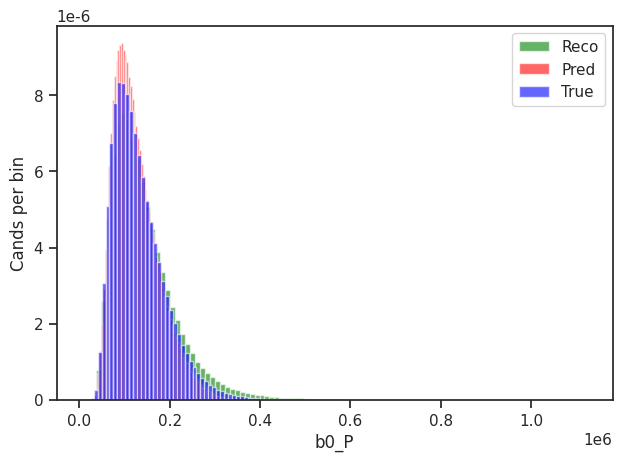

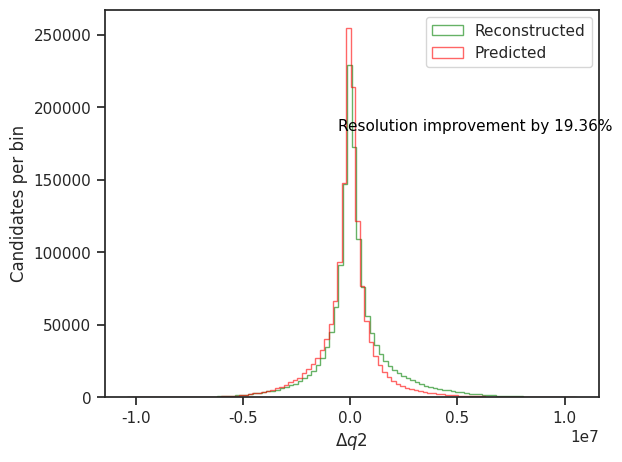

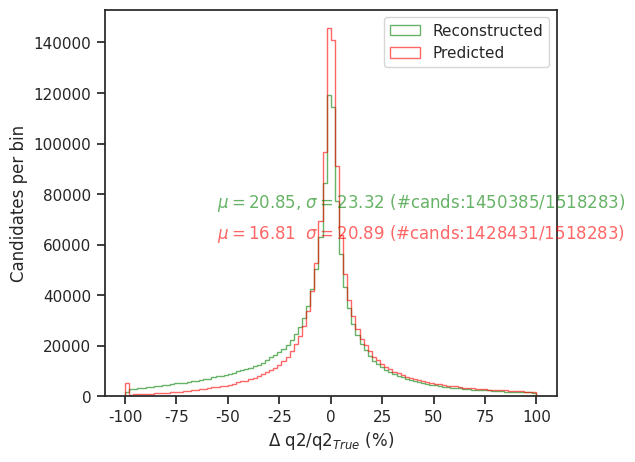

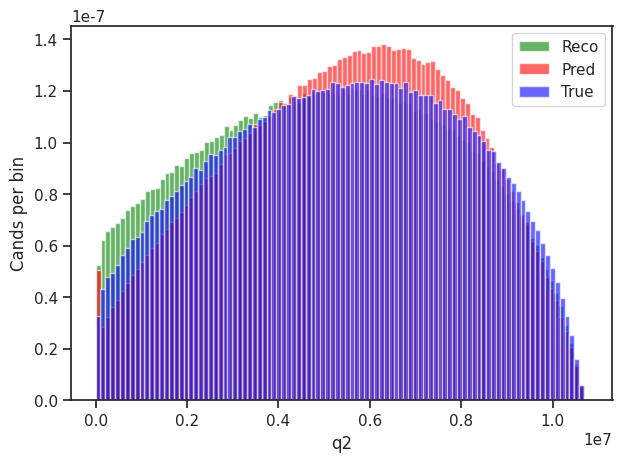

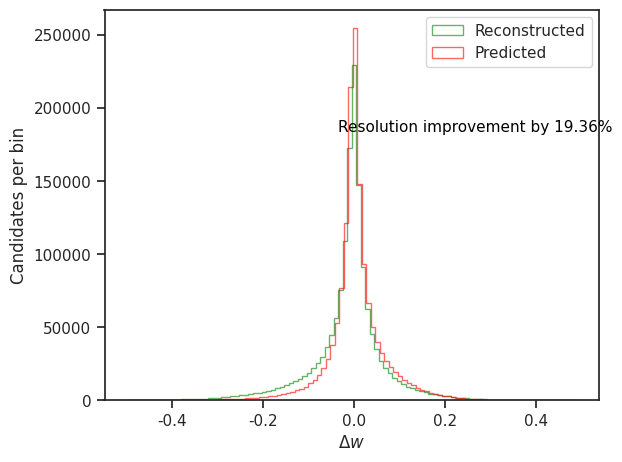

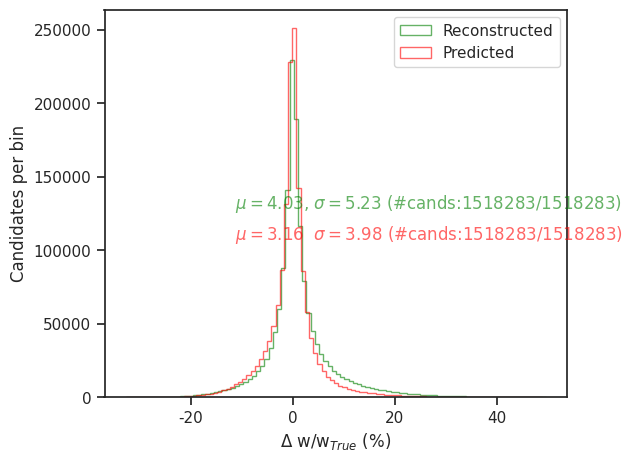

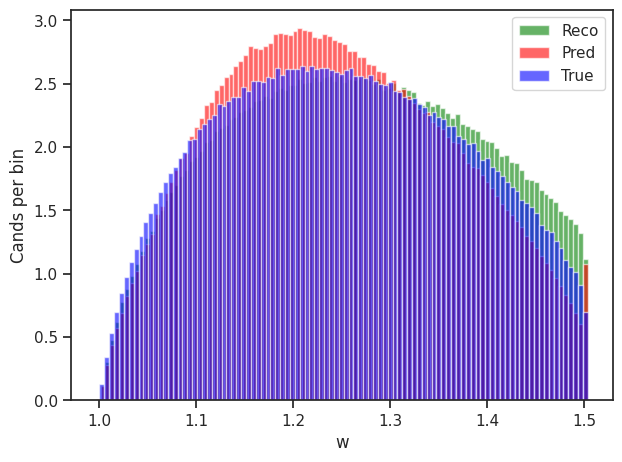

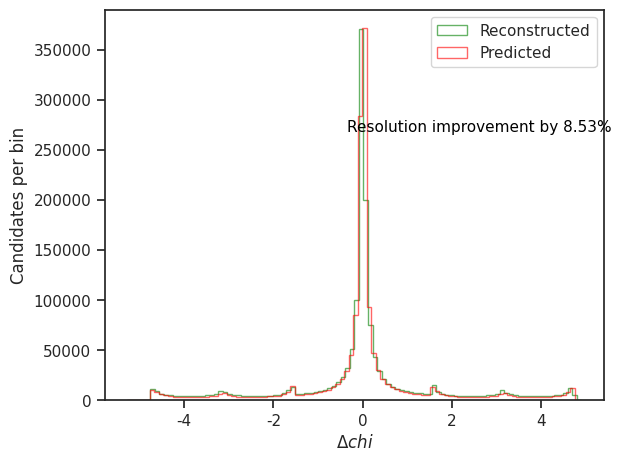

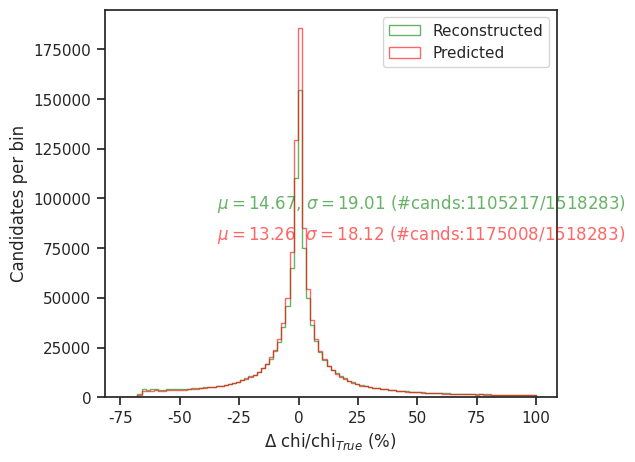

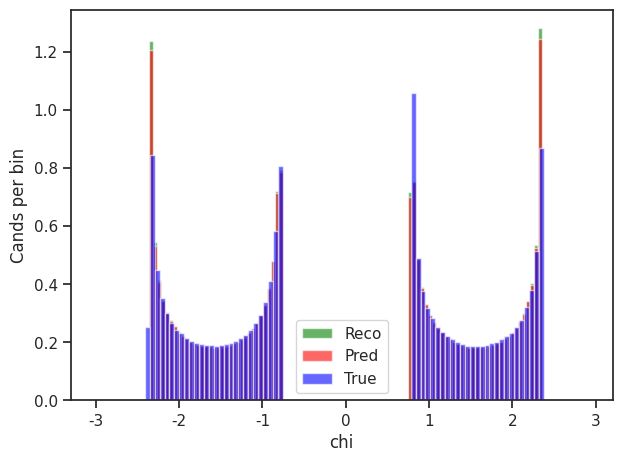

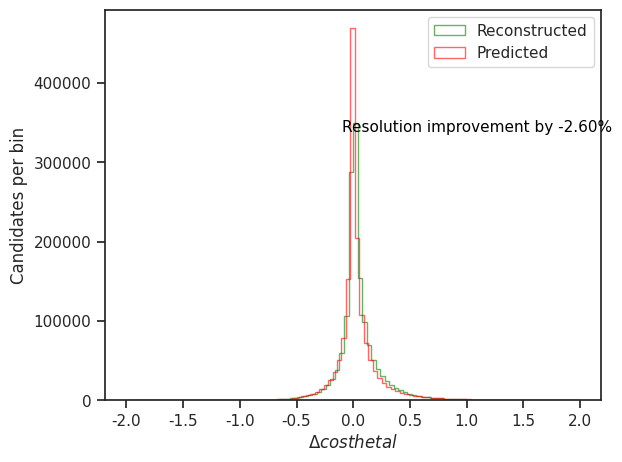

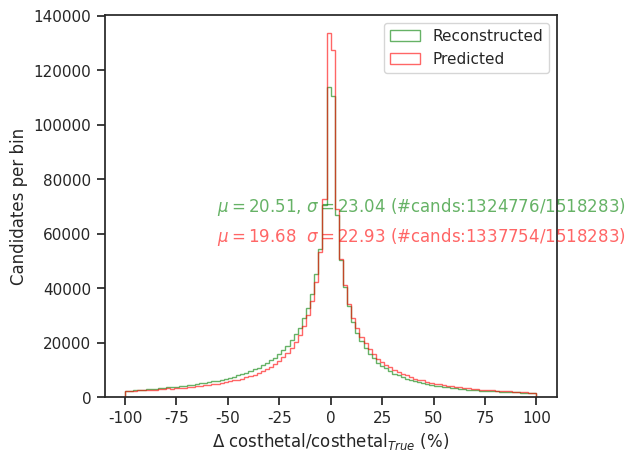

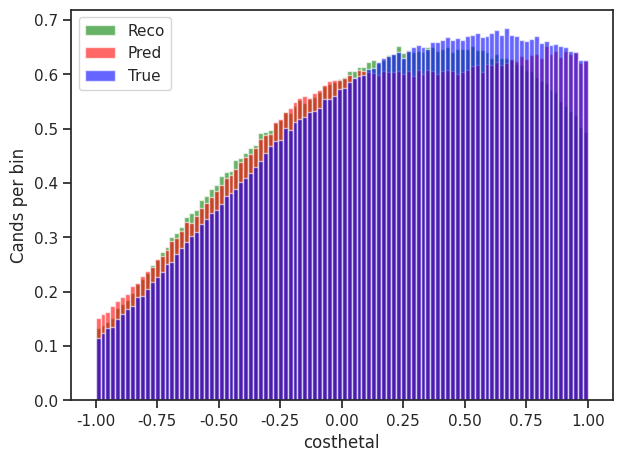

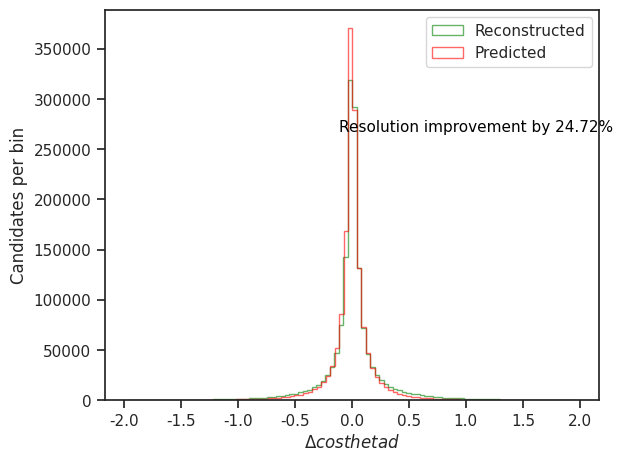

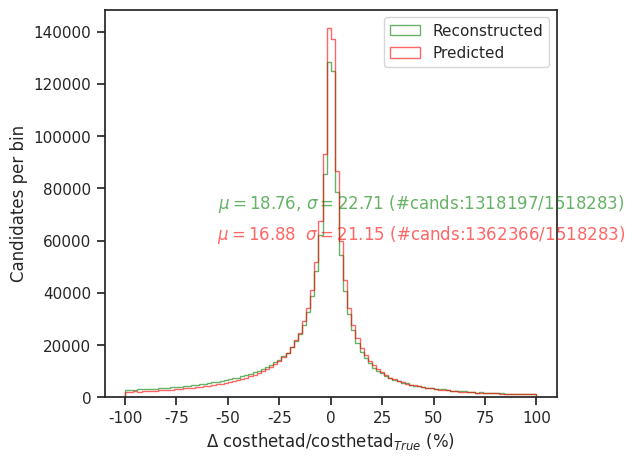

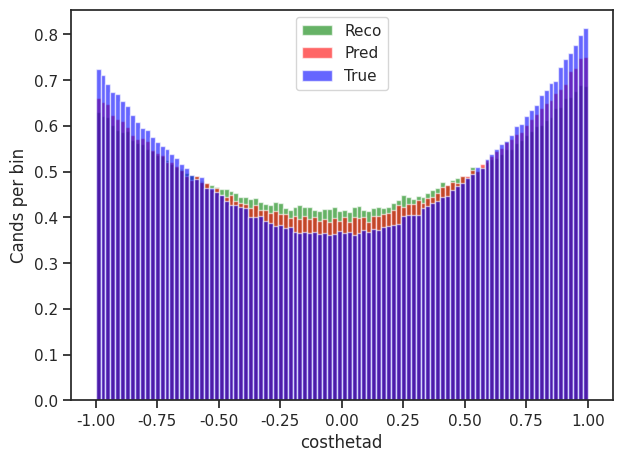

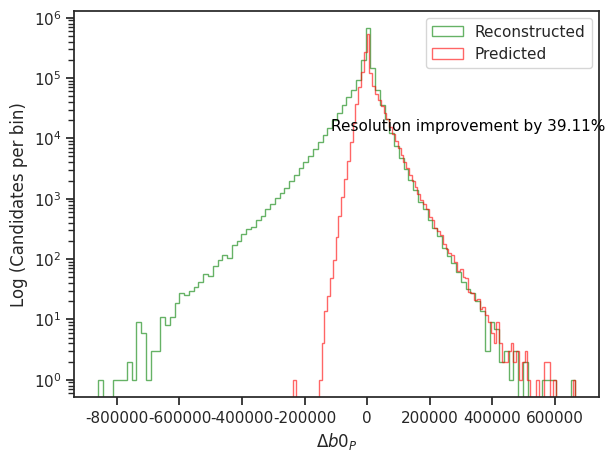

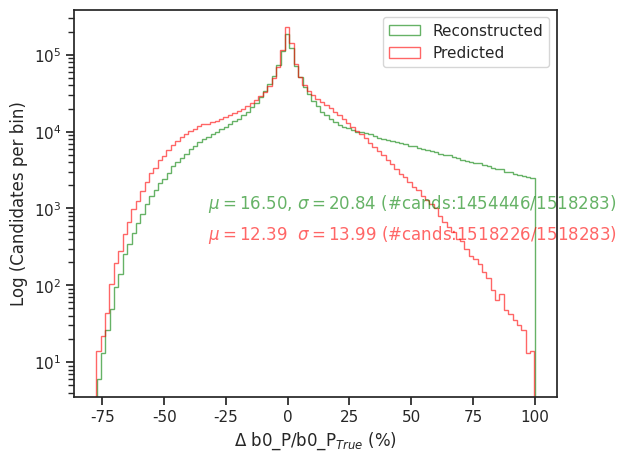

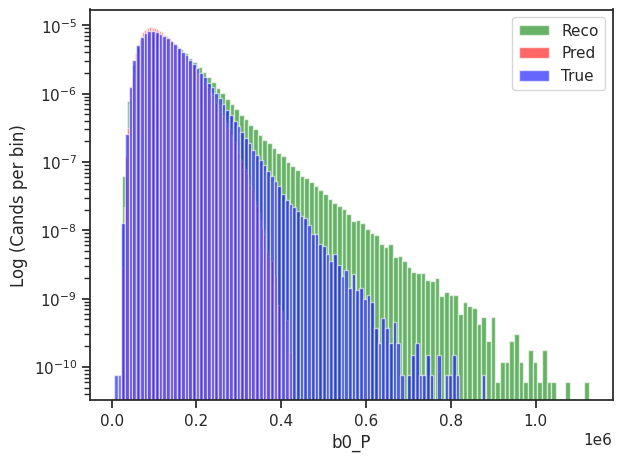

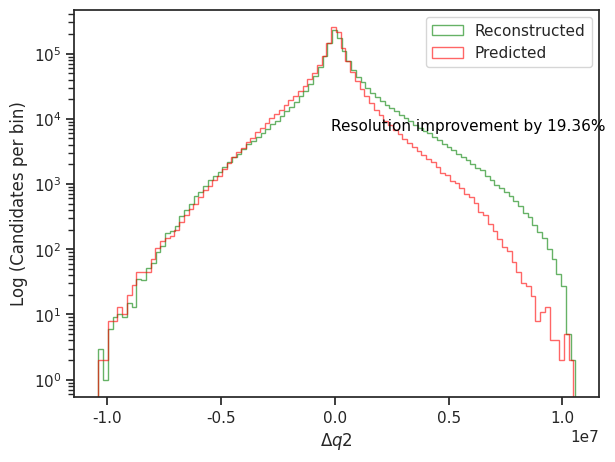

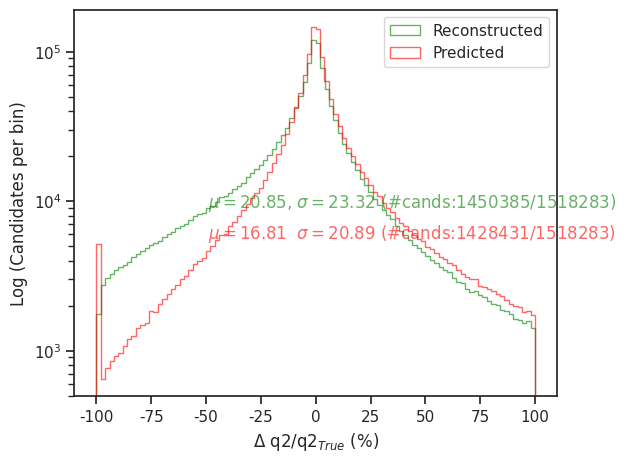

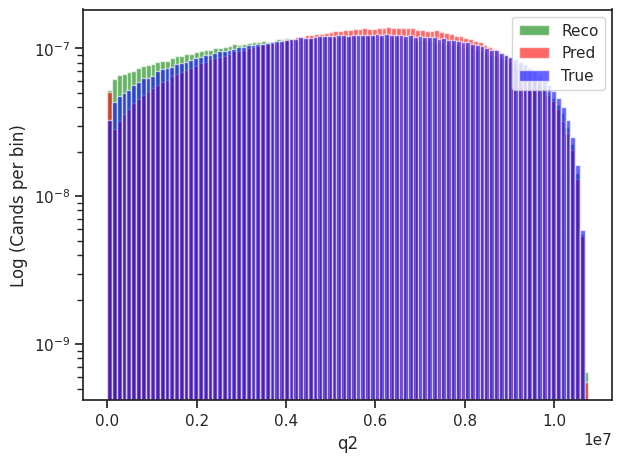

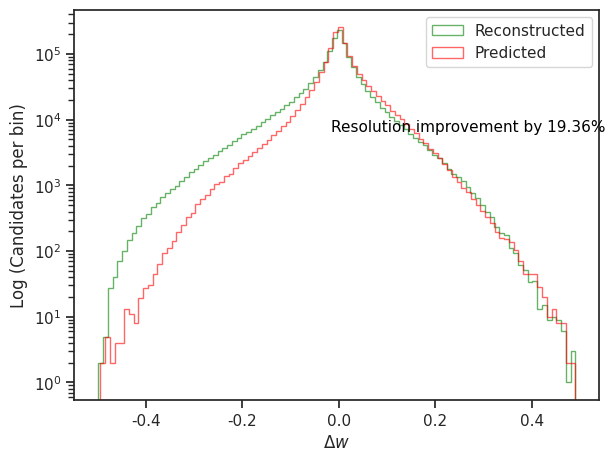

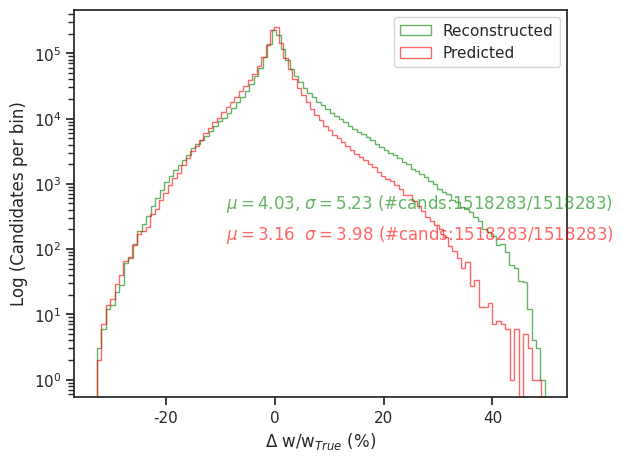

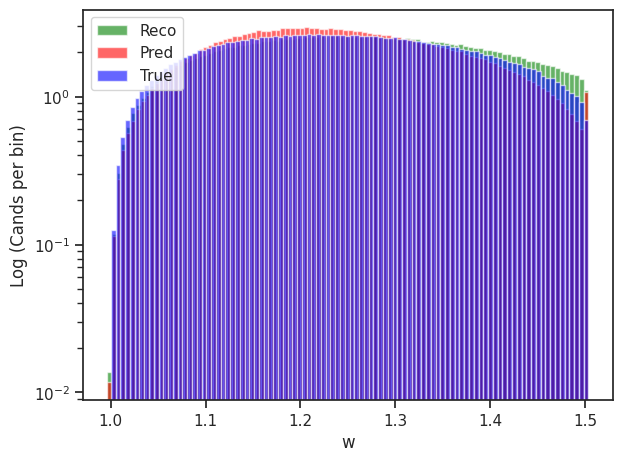

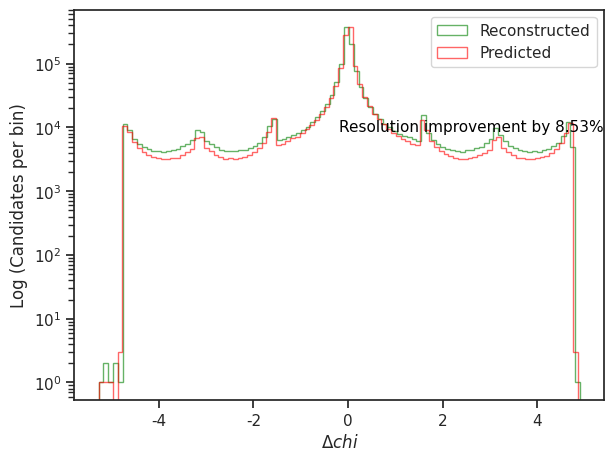

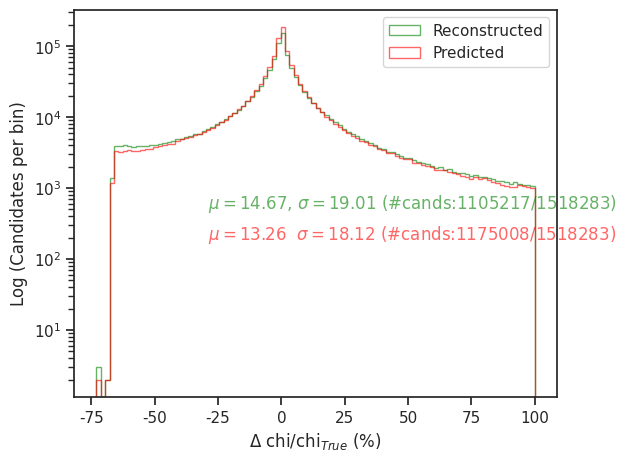

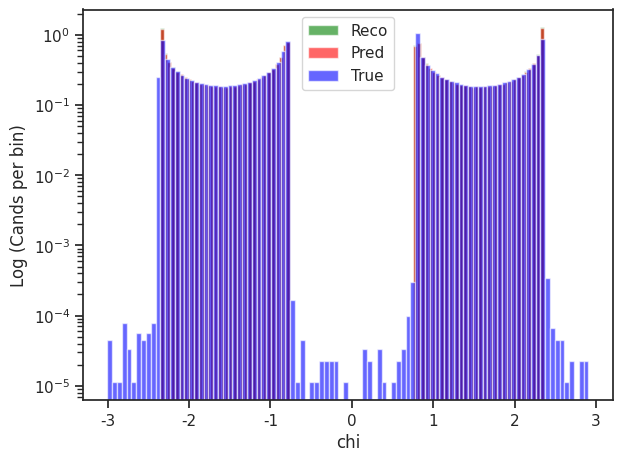

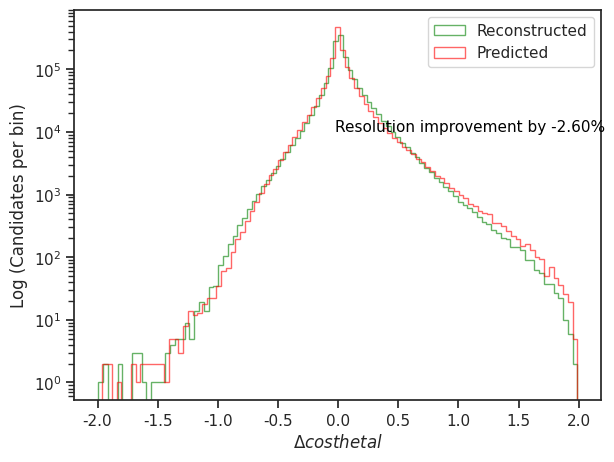

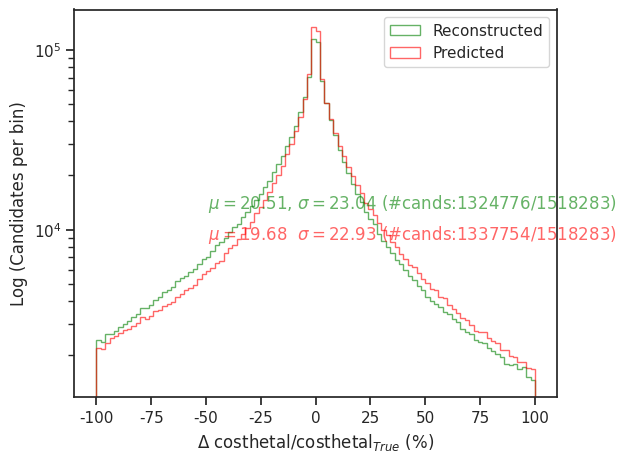

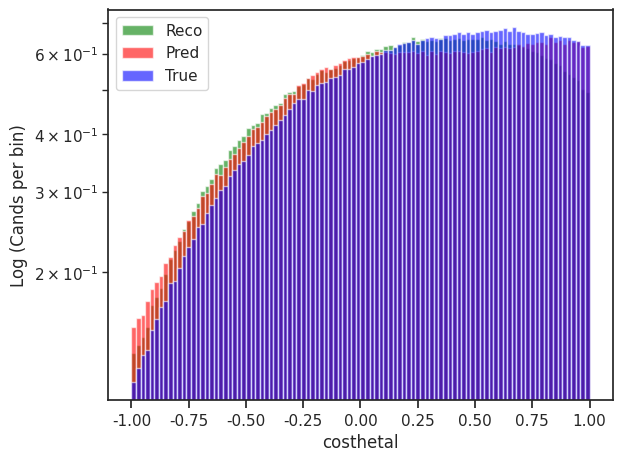

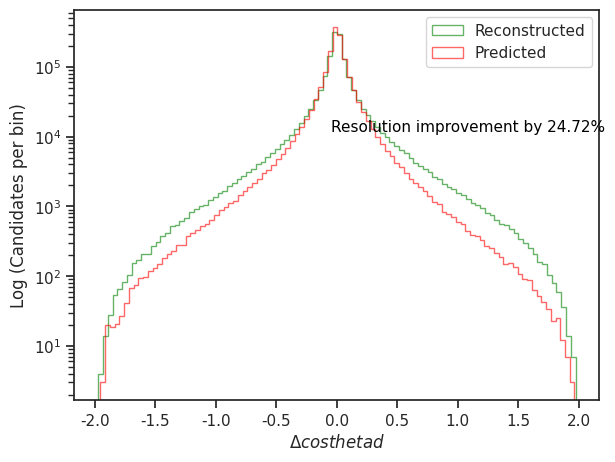

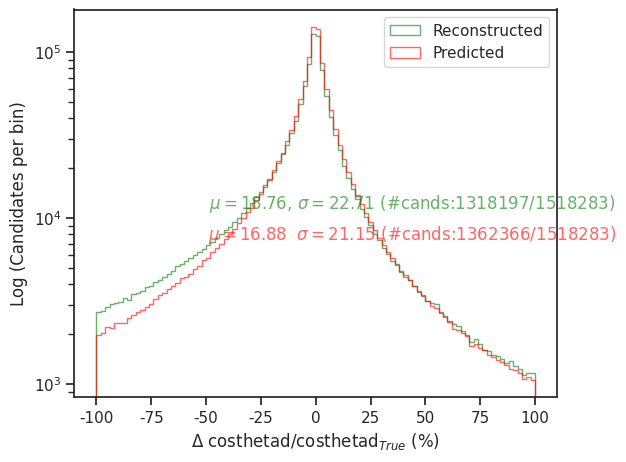

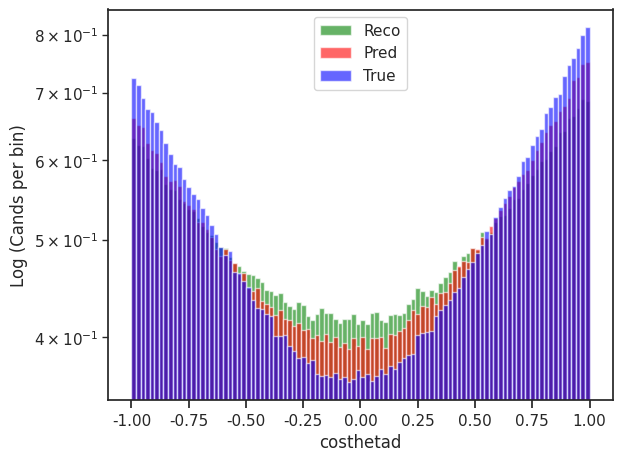

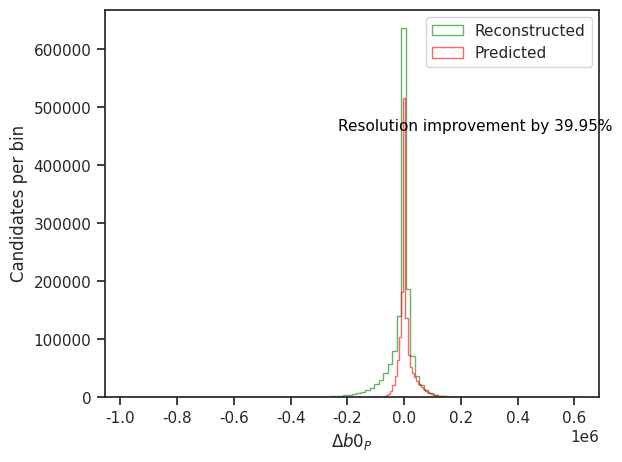

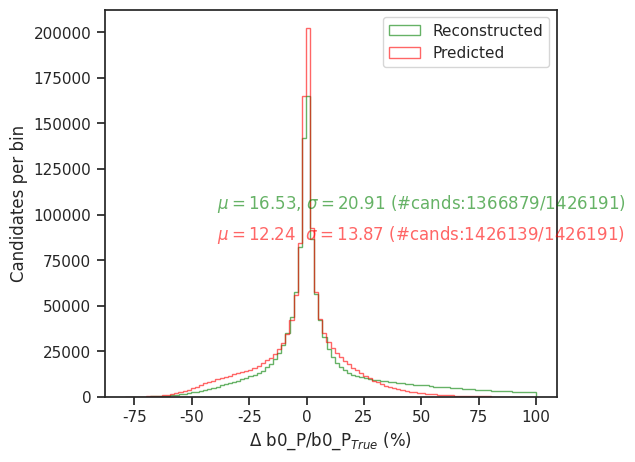

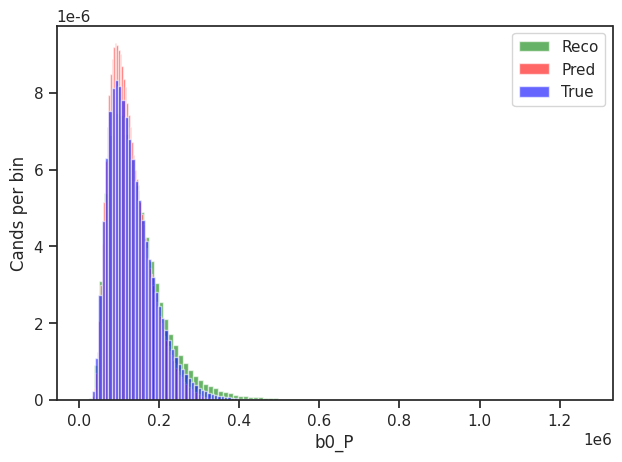

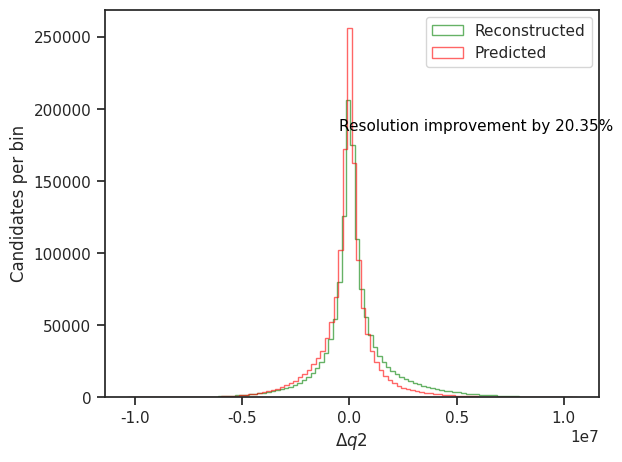

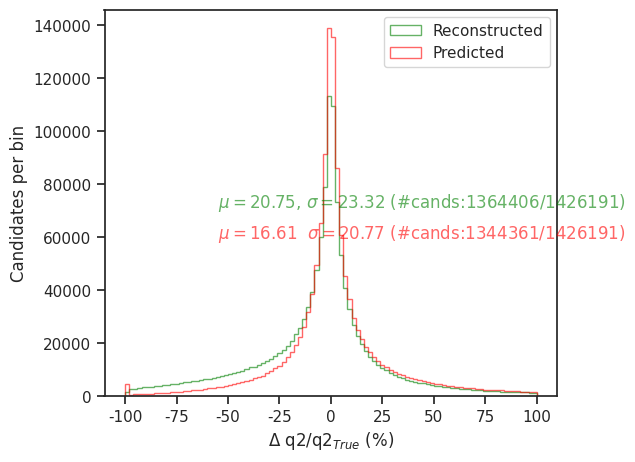

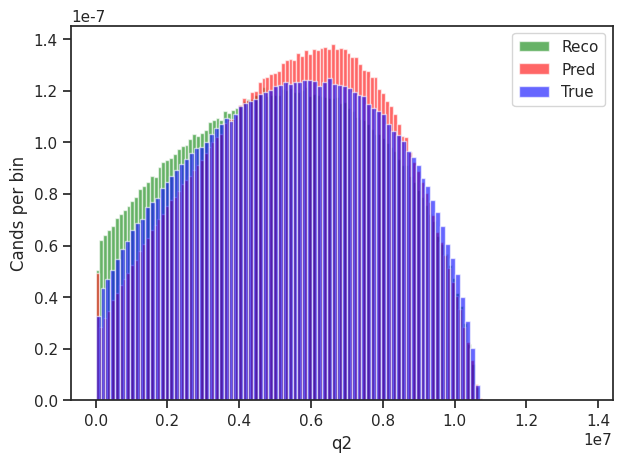

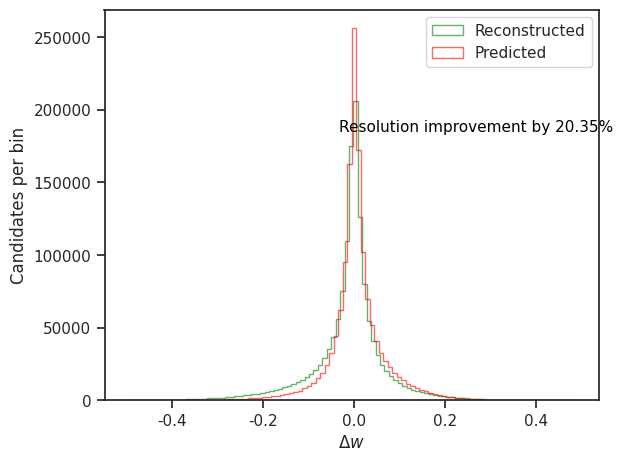

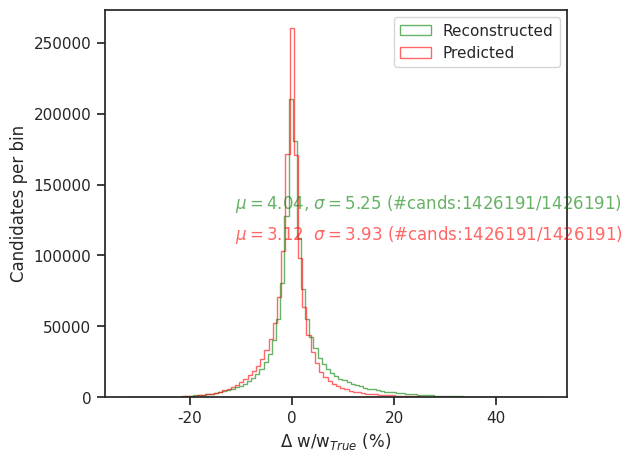

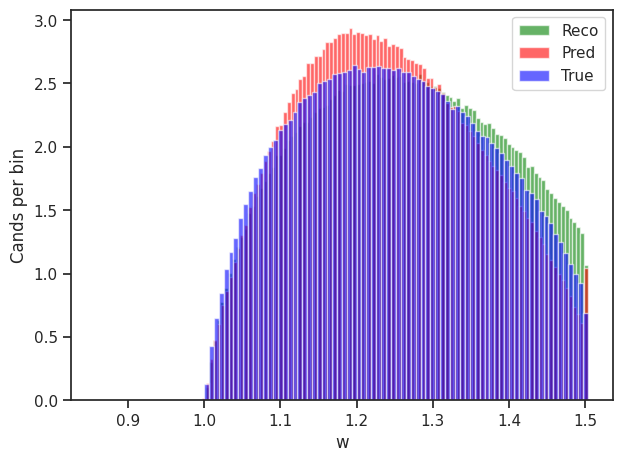

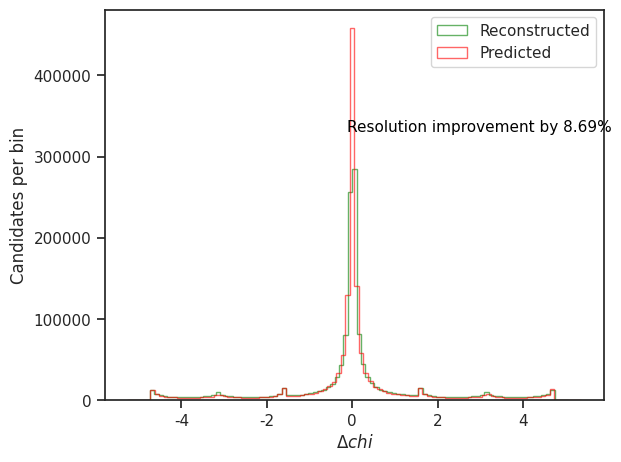

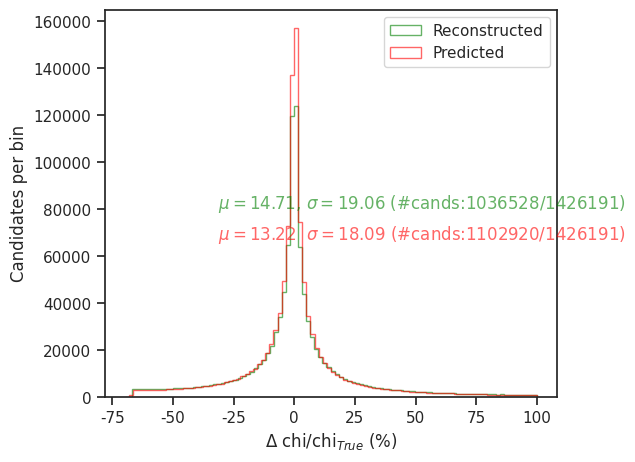

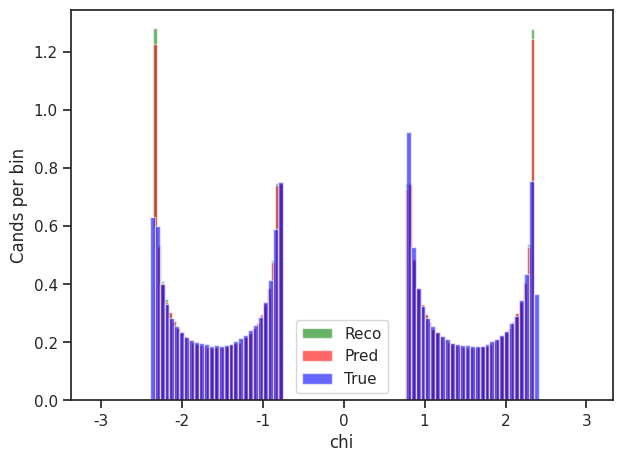

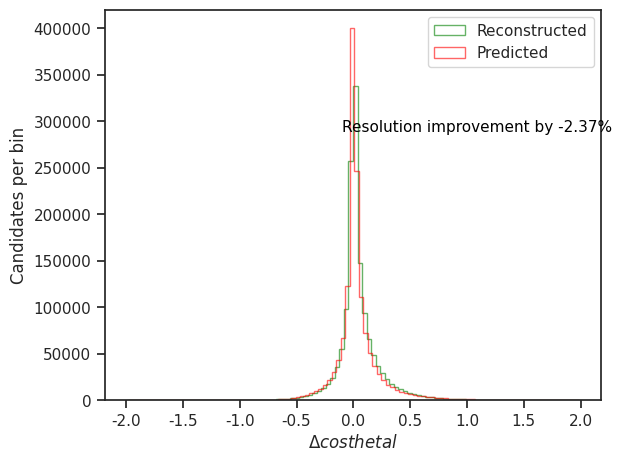

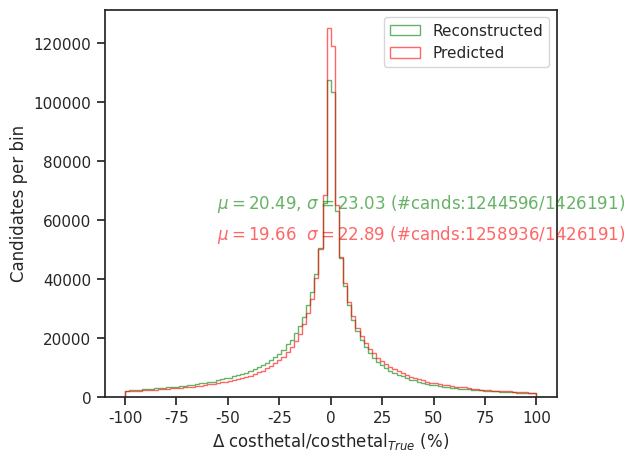

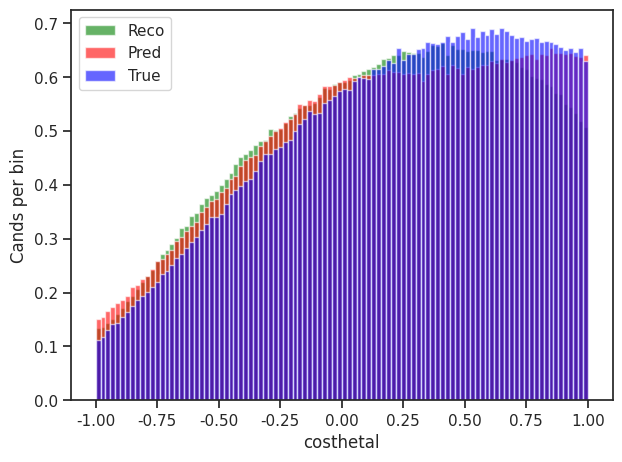

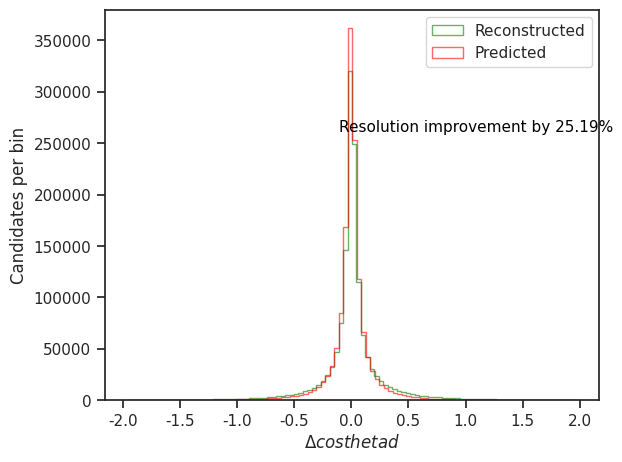

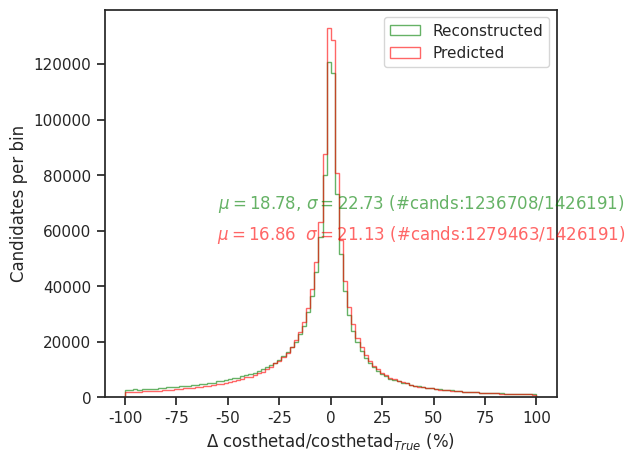

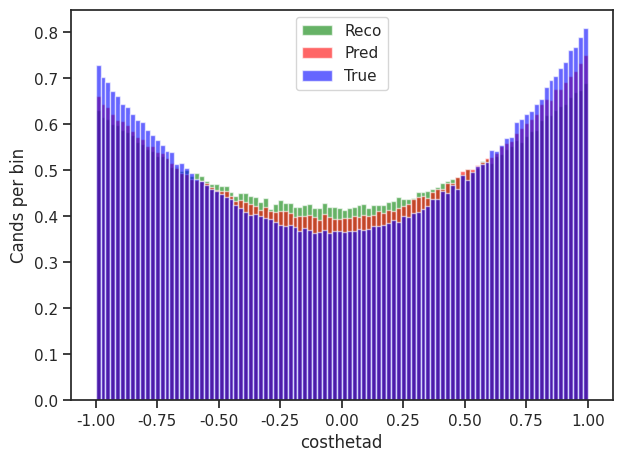

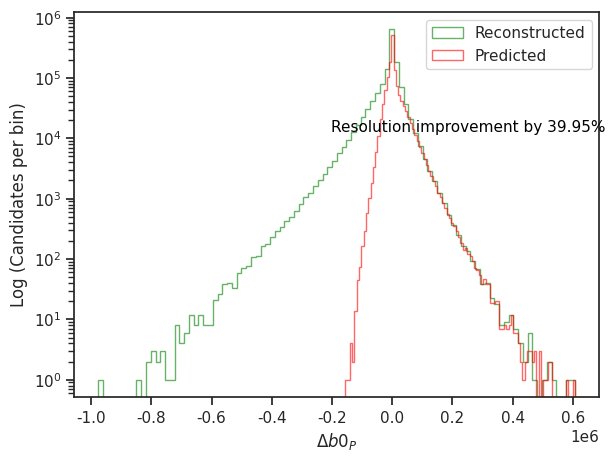

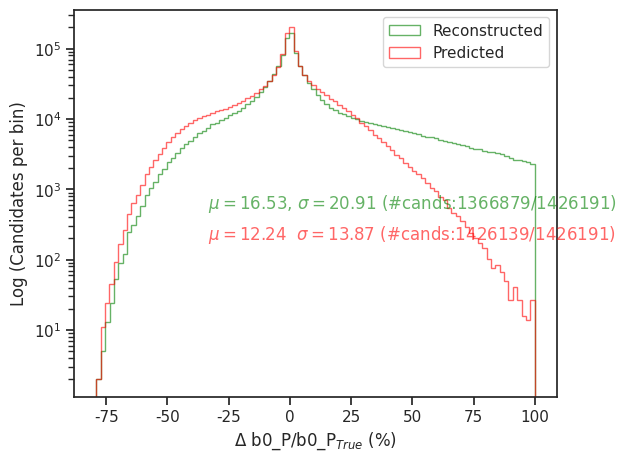

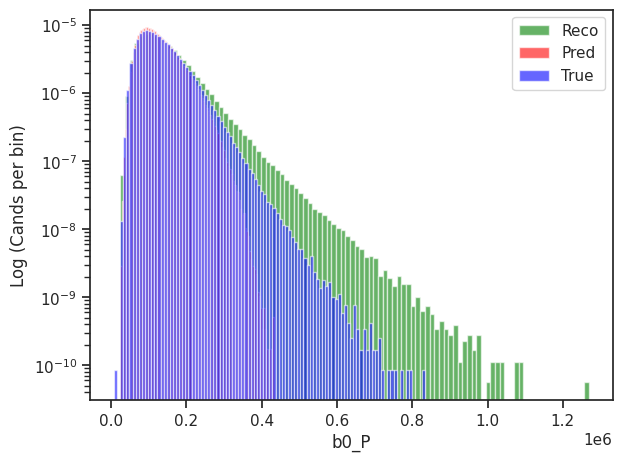

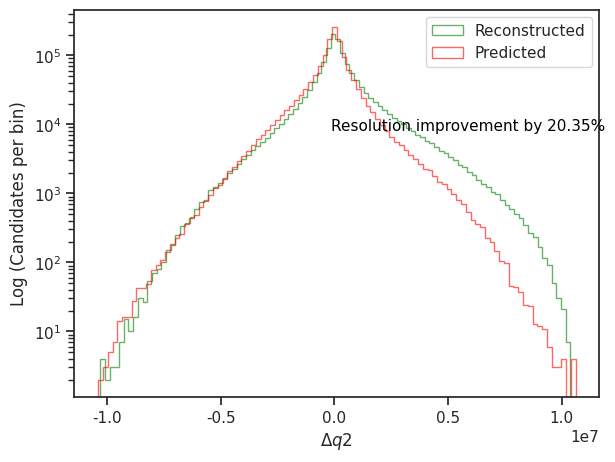

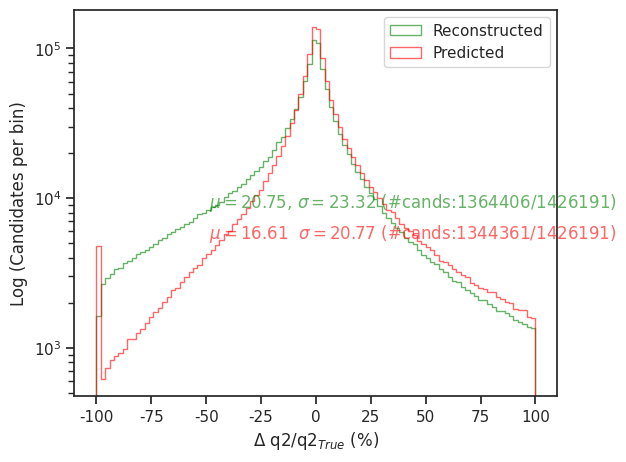

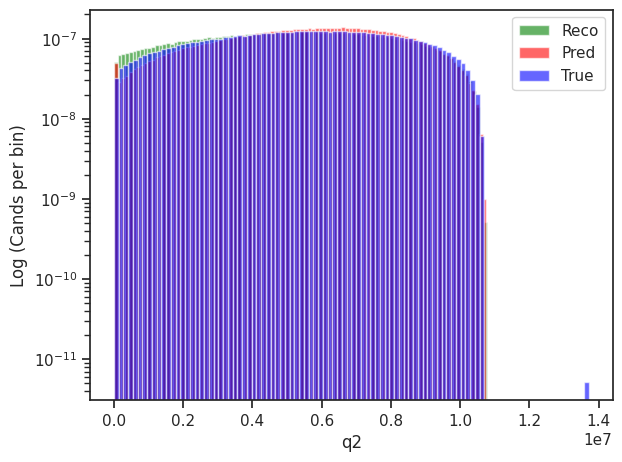

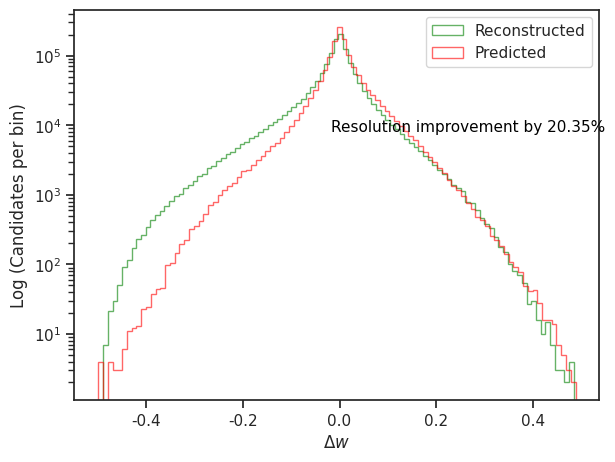

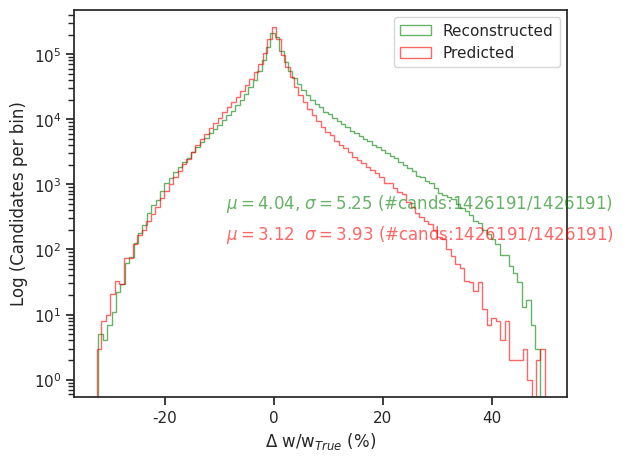

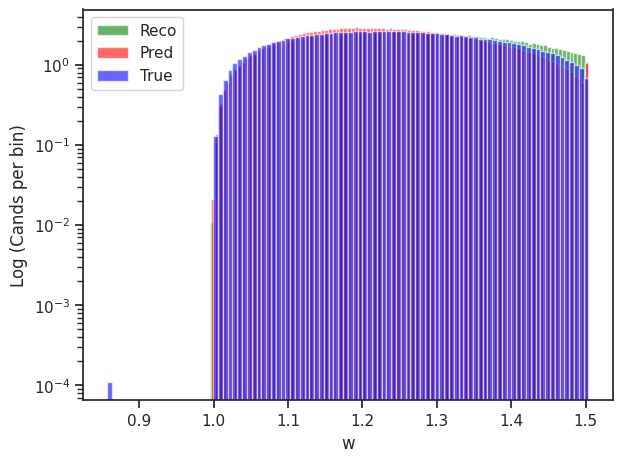

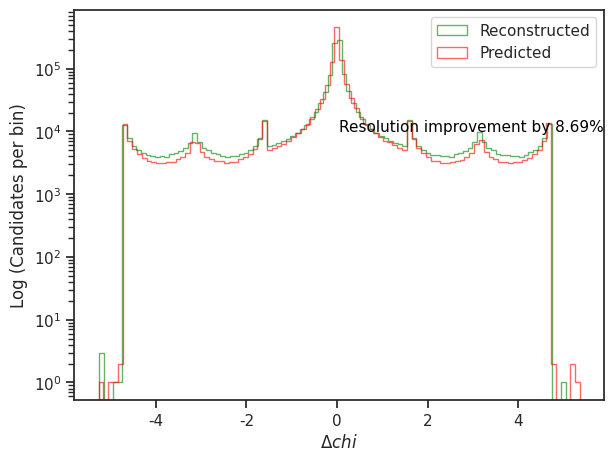

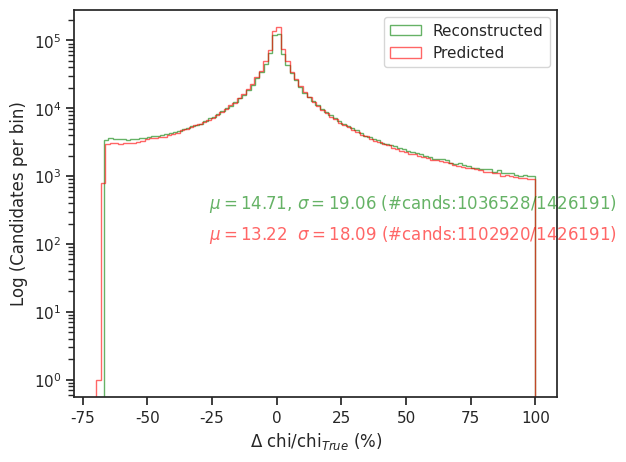

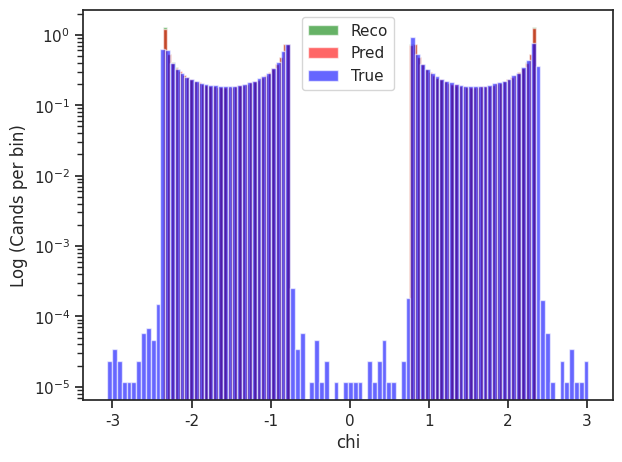

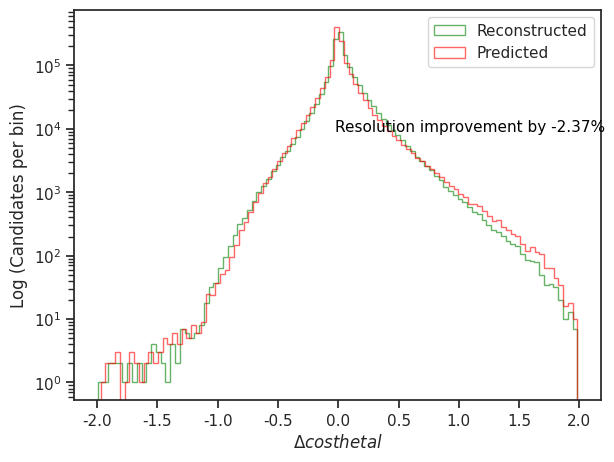

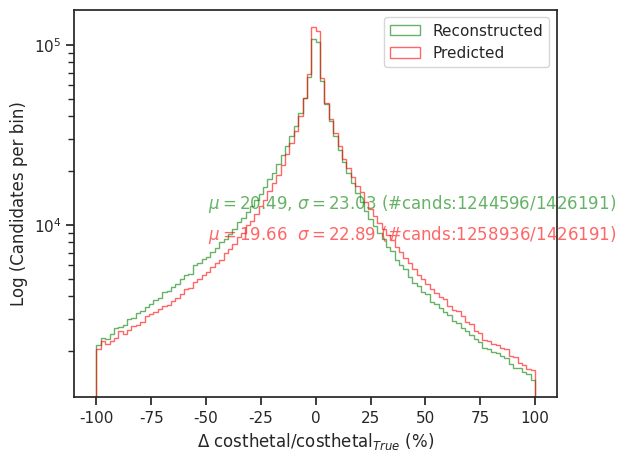

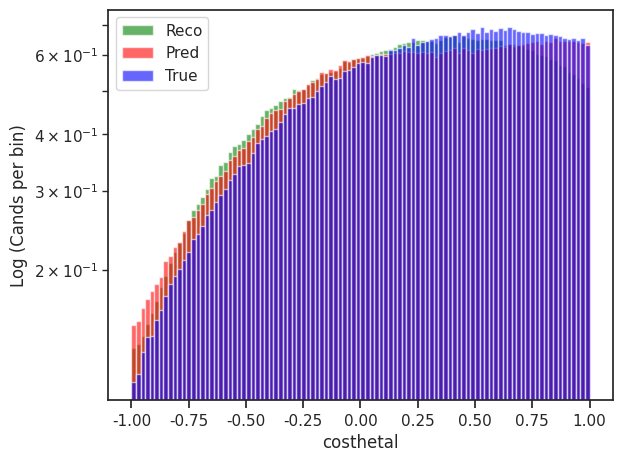

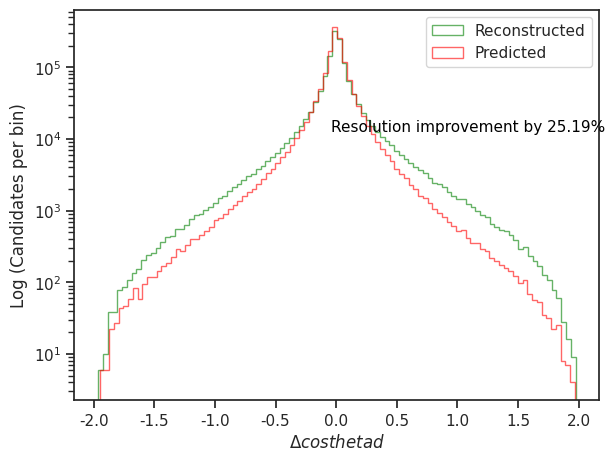

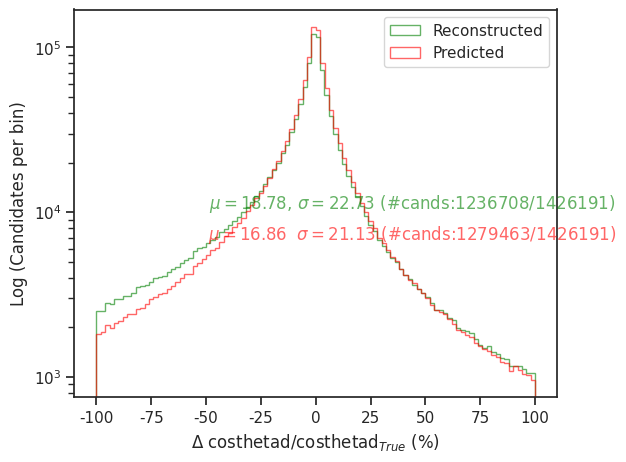

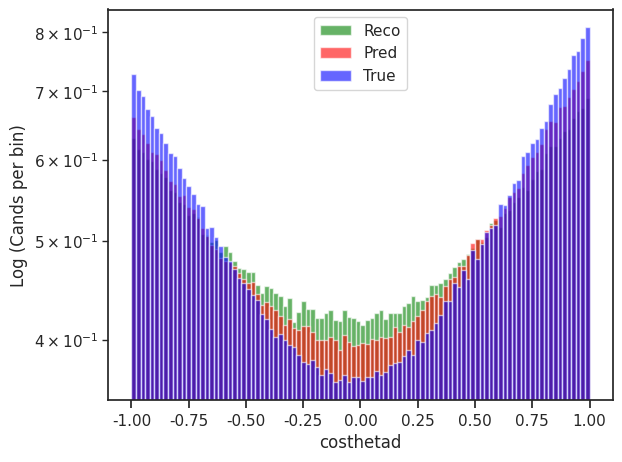

In [2]:
#!/bin/python

####################
import os, sys

year  = 2016#2016#2017#2018
magnets = ['up','down']
'''components = [
    "signal"#,
    
]
'''
#################### Import things
seed=120
import numpy as np
np.random.seed(seed=int(seed))
import pandas as pd
import pickle

import tensorflow as tf
physical_devices = tf.config.list_physical_devices('GPU')

sys.path.insert(0, '/eos/lhcb/user/h/havva/q2Measurement-BtoDstMuNu/GaussianProcessRegression/Packages/AmpliTF/')
sys.path.insert(0, "/eos/user/h/havva/.local/lib/python3.11/site-packages")

import gpflow
from gpflow.utilities import print_summary
from gpflow.config import default_float

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
scalerX = MinMaxScaler()
scalerY = MinMaxScaler()

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
sns.set(font_scale=0.9) 
sns.set(style="ticks", color_codes=True)
mpl.rcParams.update({'font.size': 12.5})
plt.rcParams['axes.unicode_minus'] = False

from util_resolution import return_phasespace, Plot, MSE, return_quadsolution, get4mom, return_boostapprox, get_fitvars
from GPFlow_Model import Model
import amplitf.kinematics as atfk

# build a rectangle in axes coords
left, width = .25, .5
bottom, height = .25, .5
right = left + width
top = bottom + height
####################

training_vars = ['dst_PX', 'dst_PY', 'dst_PZ', 'mu_PX', 'mu_PY', 'mu_PZ', 'b0_Flight_X', 'b0_Flight_Y', 'b0_Flight_Z']

target_vars   = []
target_vars  += ['b0_P_TRUE']
####################


#Define masses
mB = 5279.65000000
mDst = 2010.27000000 
ml  = 105.65837121
mTau= 1776.81991209 

####################
component = "b0_dstmunu"
#for component in components:
for mag in magnets:
    print(f"\n=== Processing component: {component} Mag {mag} ===")
    dir_tostore = f'{component}/pickled_{year}_{mag}'
    os.makedirs(f"{dir_tostore}/plots", exist_ok=True)

    # read full dataset
    df = pd.read_pickle(f'./{component}/preppedData_{year}_{mag}.p')
    print("Loaded dataset:", df.shape)

    # get saved model and scaler from Tracker Only
    os.system(f'cp ./TO_trained_model/scalerX.p {dir_tostore}/')
    os.system(f'cp ./TO_trained_model/scalerY.p {dir_tostore}/')
    os.system(f'cp ./TO_trained_model/gpflow_model_params.p {dir_tostore}/')
    os.system(f'cp ./TO_trained_model/X_train.p {dir_tostore}/')
    os.system(f'cp ./TO_trained_model/Y_train.p {dir_tostore}/')
    
    '''os.system(f'cp ./FS_trained_model_v2/scalerX.p {dir_tostore}/')
    os.system(f'cp ./FS_trained_model_v2/scalerY.p {dir_tostore}/')
    os.system(f'cp ./FS_trained_model_v2/gpflow_model_params.p {dir_tostore}/')
    os.system(f'cp ./FS_trained_model_v2/X_train.p {dir_tostore}/')
    os.system(f'cp ./FS_trained_model_v2/Y_train.p {dir_tostore}/')'''
   
    scalerX = pickle.load(open(f'{dir_tostore}/scalerX.p', "rb"))
    scalerY = pickle.load(open(f'{dir_tostore}/scalerY.p', "rb"))
    params  = pickle.load(open(f'{dir_tostore}/gpflow_model_params.p', "rb"))

    # load the training data used to define the model (needed for correct shapes)
    X_train = pickle.load(open(f'{dir_tostore}/X_train.p', "rb"))
    Y_train = pickle.load(open(f'{dir_tostore}/Y_train.p', "rb"))

    # scale training data (for model initialization only)
    X_train = scalerX.transform(X_train)
    Y_train = scalerY.transform(Y_train)

    # build model and load saved parameters
    m = Model(X_train, Y_train, seed, params)

    # ---- apply to the FULL dataset ----
    X_full = df[training_vars].values
    Y_full = df[target_vars].values  # only if you want truth for comparison
    X_full = scalerX.transform(X_full)

    # predict on full dataset
    mu_full, var_full = m.predict_y(X_full)
    mu_full = scalerY.inverse_transform(mu_full)

    # attach predictions to dataframe
    df['b0_P_Estm'] = mu_full[:, 0]

    # get Mu 4-momentum
    '''Pl_lab = atfk.lorentz_vector(
        atfk.vector(df['Lepton_PX_Reco'], df['Lepton_PY_Reco'], df['Lepton_PZ_Reco']),
        df['Lepton_E_Reco']
    )'''#commented out b/c already added in util_resolution.py/get_fitvars()
    p3_Bfd = atfk.vector(df['b0_Flight_X'], df['b0_Flight_Y'], df['b0_Flight_Z'])

    # compute fit variables
#    df = get_fitvars(df, Pl_lab, p3_Bfd, mB, '')
    df = get_fitvars(df, p3_Bfd, mB)
    df = df.dropna()

    # compute w
    df['w_Pred'] = (mB**2 + mDst**2 - df['q2_Pred']) / (2*mB*mDst)

    # save regressed dataset
    outname = f'{dir_tostore}/regressed.p'
    df.to_pickle(outname)
    print("Saved:", outname)

    # make plots
    Plot(df=df, var='b0_P', suffix='', Dir=f'{dir_tostore}/plots', log=False, res_limits_rel=(-1.,1.))
    Plot(df=df, var='q2',   suffix='', Dir=f'{dir_tostore}/plots', log=False, res_limits_rel=(-1.,1.))
    Plot(df=df, var='w',    suffix='', Dir=f'{dir_tostore}/plots', log=False, res_limits_rel=(-1.,1.))
    Plot(df=df, var='chi',    suffix='', Dir=f'{dir_tostore}/plots', log=False, res_limits_rel=(-1.,1.))
    Plot(df=df, var='costhetal',    suffix='', Dir=f'{dir_tostore}/plots', log=False, res_limits_rel=(-1.,1.))
    Plot(df=df, var='costhetad',    suffix='', Dir=f'{dir_tostore}/plots', log=False, res_limits_rel=(-1.,1.))

    
    Plot(df=df, var='b0_P', suffix='', Dir=f'{dir_tostore}/plots', log=True, res_limits_rel=(-1.,1.))
    Plot(df=df, var='q2',   suffix='', Dir=f'{dir_tostore}/plots', log=True, res_limits_rel=(-1.,1.))
    Plot(df=df, var='w',    suffix='', Dir=f'{dir_tostore}/plots', log=True, res_limits_rel=(-1.,1.))
    Plot(df=df, var='chi',    suffix='', Dir=f'{dir_tostore}/plots', log=True, res_limits_rel=(-1.,1.))
    Plot(df=df, var='costhetal',    suffix='', Dir=f'{dir_tostore}/plots', log=True, res_limits_rel=(-1.,1.))
    Plot(df=df, var='costhetad',    suffix='', Dir=f'{dir_tostore}/plots', log=True, res_limits_rel=(-1.,1.))

    print(f"Plots saved in {dir_tostore}/plots")

### Convert panda data frames to root file

In [3]:
import ROOT
import pandas as pd
import numpy as np

def df_to_root_tree(pkl_file_up, pkl_file_down ,output_root_file):
    # Load the DataFrame
    df_up = pd.read_pickle(pkl_file_up)
    df_down = pd.read_pickle(pkl_file_down)
    df = pd.concat([df_up, df_down], ignore_index=True)

    # Create ROOT file and TTree
    root_file = ROOT.TFile(output_root_file, "RECREATE")
    tree = ROOT.TTree("DecayTree", "DecayTree")

    # Create branch buffers and define branches
    branch_buffers = {}
    for col in df.columns:
        # Determine type: float or int
        dtype = df[col].dtype
        if np.issubdtype(dtype, np.floating):
            branch_buffers[col] = np.zeros(1, dtype=np.float64)
            tree.Branch(col, branch_buffers[col], f"{col}/D")
        elif np.issubdtype(dtype, np.integer):
            branch_buffers[col] = np.zeros(1, dtype=np.int64)
            tree.Branch(col, branch_buffers[col], f"{col}/I")
        else:
            print(f"Skipping non-numeric column: {col}")

    # Fill the tree
    for _, row in df.iterrows():
        for col in branch_buffers:
            branch_buffers[col][0] = row[col]
        tree.Fill()

    # Write and close
    tree.Write()
    root_file.Close()
    print(f" Saved ROOT file: {output_root_file} with TTree 'DecayTree'")

# Example usage
years=[2016]#, 2017, 2018]
base_mc_path ="/eos/lhcb/user/h/havva/q2Measurement-BtoDstMuNu/MCsamples/TrackerOnlyNTuples_Maryland/Angular_RDst_muonic_Run2/ReProcess_tuples/"
 
component="b0_dstmunu"
for year in years:
    #for component in components:
    df_to_root_tree(f"{component}/pickled_{year}_up/regressed.p",f"{component}/pickled_{year}_down/regressed.p",f"{base_mc_path}{year}/{component}_BestVariables.root")


 Saved ROOT file: /eos/lhcb/user/h/havva/q2Measurement-BtoDstMuNu/MCsamples/TrackerOnlyNTuples_Maryland/Angular_RDst_muonic_Run2/ReProcess_tuples/2016/b0_dstmunu_BestVariables.root with TTree 'DecayTree'
